## 1. 환경 설정 및 데이터 다운로드

> **핵심 내용**
> - Google Colab 실행 환경 자동 셋업 (패키지 설치, 디렉토리 생성)
> - 한국어 위키피디아 말뭉치(`kowiki.txt`) 다운로드 및 압축 해제
> - **Fast-run 모드**: 기본값으로 상위 20,000줄만 사용 (전체 학습은 `BERT_PRETRAIN_FAST_RUN=0`으로 변경)
> - SentencePiece BPE 모델이 없으면 vocab_size=8,007로 자동 학습
> - **에폭(epoch)**: 기본값 `5` → **`20`으로 상향** (학습 수렴을 위해 충분한 반복 필요)
> - **배치 크기**: `8` → **`32`로 상향** (학습 안정성 및 GPU 효율 향상)


In [1]:
# Colab 모두 실행용 셋업 셀
# 이 셀은 런타임 → 모두 실행을 눌렀을 때 필요한 파일/폴더/패키지를 자동으로 준비합니다.

import os
import sys
import subprocess
import zipfile
import urllib.request
from pathlib import Path

# 기본값은 Colab에서 끊기지 않고 끝까지 도는 빠른 실행 모드입니다.
# 그래프가 선으로 보이도록 epoch 기본값은 3으로 설정했습니다.
# 전체 데이터로 오래 학습하려면 아래 값을 "0"으로 바꾸면 됩니다.
os.environ.setdefault("BERT_PRETRAIN_FAST_RUN", "1")
os.environ.setdefault("BERT_PRETRAIN_MAX_LINES", "20000")
os.environ.setdefault("BERT_PRETRAIN_COUNT", "8192")
os.environ.setdefault("BERT_PRETRAIN_EPOCHS", "20")
os.environ.setdefault("BERT_PRETRAIN_BATCH_SIZE", "32")
os.environ.setdefault("BERT_PRETRAIN_SP_VOCAB_SIZE", "8000")

# 패키지 설치
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q",
    "sentencepiece", "tqdm", "torchinfo"
])

BASE_DIR = Path("/content") if Path("/content").exists() else Path.cwd()
os.chdir(BASE_DIR)

DATA_DIR = BASE_DIR / "data"
MODEL_DIR = BASE_DIR / "models"
WORK_DIR = BASE_DIR / "work"
for path in (DATA_DIR, MODEL_DIR, WORK_DIR):
    path.mkdir(parents=True, exist_ok=True)

CORPUS_URL = "https://d3s0tskafalll9.cloudfront.net/media/documents/kowiki.txt.zip"
zip_path = DATA_DIR / "kowiki.txt.zip"
corpus_path = DATA_DIR / "kowiki.txt"

# corpus 다운로드 및 압축 해제
if not corpus_path.exists():
    try:
        if not zip_path.exists():
            print("Downloading kowiki.txt.zip...")
            urllib.request.urlretrieve(CORPUS_URL, zip_path)

        print("Extracting kowiki.txt.zip...")
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(DATA_DIR)

        found = list(DATA_DIR.rglob("kowiki.txt"))
        if found:
            found_path = found[0]
            if found_path != corpus_path:
                corpus_path.write_text(found_path.read_text(encoding="utf-8"), encoding="utf-8")
    except Exception as e:
        print("kowiki.txt 다운로드에 실패해 샘플 corpus로 대체합니다.")
        print("실제 학습을 하려면 data/kowiki.txt를 직접 업로드하세요.")
        sample_text = """
인공지능은 컴퓨터가 사람처럼 학습하고 추론하도록 만드는 기술이다.
자연어 처리는 사람이 사용하는 언어를 컴퓨터가 이해하도록 만드는 분야이다.
BERT는 Transformer encoder 구조를 기반으로 만들어진 언어 모델이다.
Masked Language Modeling은 일부 토큰을 가리고 원래 토큰을 맞히는 학습 방식이다.
Next Sentence Prediction은 두 문장이 이어지는지 판단하는 학습 방식이다.

딥러닝 모델은 많은 데이터를 사용하여 패턴을 학습한다.
토크나이저는 문장을 작은 단위의 토큰으로 나누는 역할을 한다.
SentencePiece는 subword 기반 토크나이저를 만들 때 자주 사용된다.
""".strip()
        corpus_path.write_text((sample_text + "\n\n") * 2000, encoding="utf-8")

# 빠른 실행 모드에서는 corpus 일부만 사용합니다.
fast_run = os.environ.get("BERT_PRETRAIN_FAST_RUN", "1") == "1"
if fast_run:
    max_lines = int(os.environ.get("BERT_PRETRAIN_MAX_LINES", "20000"))
    run_corpus_path = DATA_DIR / "kowiki_colab_small.txt"
    if not run_corpus_path.exists():
        print(f"Creating small corpus for fast run: first {max_lines} lines")
        with open(corpus_path, "r", encoding="utf-8") as in_f, open(run_corpus_path, "w", encoding="utf-8") as out_f:
            for i, line in enumerate(in_f):
                if i >= max_lines:
                    break
                out_f.write(line)
else:
    run_corpus_path = corpus_path

os.environ["BERT_PRETRAIN_CORPUS_FILE"] = str(run_corpus_path)

# SentencePiece 모델이 없으면 자동 생성합니다.
# 빠른 실행을 위해 기본 vocab size는 8000으로 둡니다.
import sentencepiece as spm
model_path = DATA_DIR / "ko_32000.model"
if not model_path.exists() and not (MODEL_DIR / "ko_32000.model").exists():
    sp_vocab_size = int(os.environ.get("BERT_PRETRAIN_SP_VOCAB_SIZE", "8000"))
    prefix = DATA_DIR / "ko_32000"
    print(f"Training SentencePiece model. vocab_size={sp_vocab_size + 7}")
    spm.SentencePieceTrainer.train(
        f"--input={run_corpus_path} "
        f"--model_prefix={prefix} "
        f"--vocab_size={sp_vocab_size + 7} "
        "--model_type=bpe "
        "--max_sentence_length=999999 "
        "--pad_id=0 --pad_piece=[PAD] "
        "--unk_id=1 --unk_piece=[UNK] "
        "--bos_id=2 --bos_piece=[BOS] "
        "--eos_id=3 --eos_piece=[EOS] "
        "--user_defined_symbols=[SEP],[CLS],[MASK] "
        "--hard_vocab_limit=false"
    )

print("Colab setup finished.")
print("corpus_file:", os.environ["BERT_PRETRAIN_CORPUS_FILE"])
print("fast_run:", fast_run)
print("train_count:", os.environ["BERT_PRETRAIN_COUNT"])
print("epochs:", os.environ["BERT_PRETRAIN_EPOCHS"])
print("batch_size:", os.environ["BERT_PRETRAIN_BATCH_SIZE"])


Colab setup finished.
corpus_file: /home/jovyan/work/bert_pretrain/data/kowiki_colab_small.txt
fast_run: True
train_count: 8192
epochs: 20
batch_size: 32


## 2. Tokenizer 준비

> **핵심 내용**
> - PyTorch, NumPy, SentencePiece 등 주요 라이브러리 임포트 및 랜덤 시드(`1234`) 고정
> - SentencePiece BPE 토크나이저 로드 (`ko_32000.model`)
> - `REAL_VOCAB_SIZE` 확인 후 `[CLS]`, `[SEP]`, `[MASK]` 등 특수 토큰 7개 제외한 vocab 목록 구성
> - 예시 문장으로 `[CLS] 문장A [SEP] 문장B [SEP]` 형태 토크나이징 확인


In [2]:
# 2. Tokenizer 준비

In [3]:
# imports
from __future__ import absolute_import, division, print_function, unicode_literals

import os
import re
import math
import random
import collections
import json
import shutil
import zipfile
import copy
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import sentencepiece as spm
from tqdm.auto import tqdm

random_seed = 1234
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)

# torch version
print(torch.__version__)

2.7.1+cu118


In [4]:
import sentencepiece as spm
from pathlib import Path

# Colab setup cell에서 지정한 corpus 파일을 사용합니다.
data_dir = Path("data")
model_dir = Path("models")
corpus_file = Path(os.environ.get("BERT_PRETRAIN_CORPUS_FILE", str(data_dir / "kowiki.txt")))
prefix = data_dir / "ko_32000"
vocab_size = 32000

# SentencePiece 모델은 첫 번째 Colab setup cell에서 자동 생성됩니다.
# 직접 만들고 싶으면 아래 코드를 참고해 주석을 해제하면 됩니다.
# spm.SentencePieceTrainer.train(
#     f"--input={corpus_file} "
#     f"--model_prefix={prefix} "
#     f"--vocab_size={vocab_size + 7} "
#     "--model_type=bpe "
#     "--max_sentence_length=999999 "
#     "--pad_id=0 --pad_piece=[PAD] "
#     "--unk_id=1 --unk_piece=[UNK] "
#     "--bos_id=2 --bos_piece=[BOS] "
#     "--eos_id=3 --eos_piece=[EOS] "
#     "--user_defined_symbols=[SEP],[CLS],[MASK] "
#     "--hard_vocab_limit=false"
# )


In [5]:
# vocab loading
candidate_model_paths = [
    data_dir / "ko_32000.model",
    model_dir / "ko_32000.model",
]
model_path = next((path for path in candidate_model_paths if path.exists()), None)

if model_path is None:
    raise FileNotFoundError(
        "ko_32000.model을 찾을 수 없습니다. "
        "첫 번째 Colab setup cell이 정상적으로 실행되었는지 확인하세요."
    )

vocab = spm.SentencePieceProcessor()
vocab.load(str(model_path))
REAL_VOCAB_SIZE = vocab.get_piece_size()
print("Loaded SentencePiece model:", model_path)
print("REAL_VOCAB_SIZE:", REAL_VOCAB_SIZE)


Loaded SentencePiece model: data/ko_32000.model
REAL_VOCAB_SIZE: 8007


In [6]:
vocab_list = []
for token_id in range(7, vocab.get_piece_size()):
    if not vocab.is_unknown(token_id):
        vocab_list.append(vocab.id_to_piece(token_id))

print("vocab_list size:", len(vocab_list))
print(vocab_list[:100])


vocab_list size: 8000
['▁이', '▁1', '으로', '▁있', '에서', '▁그', '▁대', '▁사', '▁수', '▁2', '었다', '▁기', '▁가', '▁한', '▁전', '▁정', '▁지', '▁있다', '하는', '▁19', '하였', '▁아', '▁다', '▁시', '했다', '▁것', '▁중', '▁일', '이다', '▁자', '▁제', '▁유', '▁공', '▁인', '▁주', '▁하', '▁등', '하였다', '▁경', '▁위', '하고', '하여', '00', '▁의', '▁국', '되었다', '▁보', '한다', '▁나', '▁연', '▁발', '▁비', '에는', '▁조', '▁소', '▁모', '▁개', '▁부', '▁영', '으며', '▁미', '▁때', '▁3', '▁동', '▁세', '▁관', '▁해', '▁구', '적인', '▁오', '▁여', '▁고', '▁상', '▁문', '▁서', '▁같', '▁않', 'or', '▁도', '▁대한', '적으로', '▁만', '▁방', '▁선', '▁"', '▁사용', '▁통', '▁또', '▁생', '▁프', 'la', '이라', '▁마', '▁내', '▁따', '▁성', '▁후', '▁실', '▁스', '▁신']


In [7]:
# [CLS], tokens a, [SEP], tokens b, [SEP] 형태의 token 생성
string_a = "추적추적 비가 내리는 날이었어 그날은 왠지 손님이 많아 첫 번에 삼십 전 둘째번 오십 전 오랜만에 받아보는 십 전짜리 백통화 서푼에"
string_b = "손바닥 위엔 기쁨의 눈물이 흘러 컬컬한 목에 모주 한잔을 적셔 몇 달 포 전부터 콜록거리는 아내 생각에 그토록 먹고 싶다던"
tokens_org = ["[CLS]"] + vocab.encode_as_pieces(string_a) + ["[SEP]"] + vocab.encode_as_pieces(string_b) + ["[SEP]"]
print(tokens_org)

['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많아', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘째', '번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러', '▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전', '부터', '▁콜', '록', '거', '리는', '▁아내', '▁생각', '에', '▁그', '토', '록', '▁먹', '고', '▁싶', '다', '던', '[SEP]']


## 3. 데이터 전처리

### (1) MLM 마스크 생성

> **핵심 내용**
> - `create_pretrain_mask()`: 전체 토큰의 15%를 대상으로 whole-word 단위 마스킹
> - BERT 원칙 80/10/10 규칙 적용: 80% `[MASK]` 교체 / 10% 원본 유지 / 10% 랜덤 토큰 치환
> - SentencePiece `▁` 접두사 기반으로 단어 경계를 인식하여 단어 단위 마스킹 구현


In [8]:
def create_pretrain_mask(tokens, mask_cnt, vocab_list, rng=None):
    """
    마스크 생성
    :param tokens: tokens
    :param mask_cnt: mask 개수
    :param vocab_list: vocab list (random token 용)
    :param rng: 테스트 재현성을 위한 random-like 객체
    :return tokens: mask된 tokens
    :return mask_idx: mask된 token의 index
    :return mask_label: mask된 token의 원래 값
    """
    rng = rng or random
    tokens = list(tokens)  # 원본 리스트를 직접 변경하지 않도록 복사

    valid_token_indices = [
        i for i, token in enumerate(tokens)
        if token not in ("[CLS]", "[SEP]")
    ]
    if not valid_token_indices or mask_cnt <= 0:
        return tokens, [], []

    mask_cnt = min(mask_cnt, len(valid_token_indices))

    # 단어 단위로 mask 하기 위해서 index 분할 (SentencePiece의 ▁는 단어 시작)
    cand_idx = []
    for i in valid_token_indices:
        token = tokens[i]
        if 0 < len(cand_idx) and not token.startswith(u"\u2581"):
            cand_idx[-1].append(i)
        else:
            cand_idx.append([i])

    rng.shuffle(cand_idx)

    mask_lms = []
    covered = set()
    for index_set in cand_idx:
        if len(mask_lms) >= mask_cnt:
            break
        if any(index in covered for index in index_set):
            continue
        if len(mask_lms) + len(index_set) > mask_cnt:
            continue

        dice = rng.random()
        for index in index_set:
            if dice < 0.8:          # 80% replace with [MASK]
                masked_token = "[MASK]"
            elif dice < 0.9:        # 10% keep original
                masked_token = tokens[index]
            else:                   # 10% random word
                masked_token = rng.choice(vocab_list)

            mask_lms.append({"index": index, "label": tokens[index]})
            covered.add(index)
            tokens[index] = masked_token

    # 너무 긴 whole-word 후보만 있어 하나도 선택되지 않는 경우 방지
    if not mask_lms:
        for index in valid_token_indices[:mask_cnt]:
            dice = rng.random()
            if dice < 0.8:
                masked_token = "[MASK]"
            elif dice < 0.9:
                masked_token = tokens[index]
            else:
                masked_token = rng.choice(vocab_list)

            mask_lms.append({"index": index, "label": tokens[index]})
            tokens[index] = masked_token

    # mask_lms 정렬 후 mask_idx, mask_label 추출
    mask_lms = sorted(mask_lms, key=lambda x: x["index"])
    mask_idx = [p["index"] for p in mask_lms]
    mask_label = [p["label"] for p in mask_lms]

    return tokens, mask_idx, mask_label

### (2) NSP (Next Sentence Prediction) 페어 생성

> **핵심 내용**
> - `trim_tokens()`: 두 문장 합이 max_seq를 넘지 않도록 긴 쪽부터 잘라냄
> - `create_pretrain_instances()`: 50% 확률로 문장 순서를 뒤집어 Negative NSP 샘플 생성
> - 각 인스턴스: `tokens`, `segment`, `is_next`, `mask_idx`, `mask_label` 포함


In [9]:
def trim_tokens(tokens_a, tokens_b, max_seq):
    """
    tokens_a, tokens_b의 길이를 줄임 최대 길이: max_seq
    :param tokens_a: tokens A
    :param tokens_b: tokens B
    :param max_seq: 두 tokens 길이의 최대 값
    """
    while True:
        total_length = len(tokens_a) + len(tokens_b)
        if total_length <= max_seq:
            break

        if len(tokens_a) > len(tokens_b):
            del tokens_a[0]
        else:
            tokens_b.pop()

In [10]:
def create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list):
    """
    doc별 pretrain 데이터 생성
    """
    # for [CLS], [SEP], [SEP]
    max_seq = n_seq - 3

    instances = []
    current_chunk = []
    current_length = 0

    for i in range(len(doc)):
        current_chunk.append(doc[i])
        current_length += len(doc[i])

        if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):
            a_end = random.randrange(1, len(current_chunk))

            tokens_a = []
            for j in range(a_end):
                tokens_a.extend(current_chunk[j])

            tokens_b = []
            for j in range(a_end, len(current_chunk)):
                tokens_b.extend(current_chunk[j])

            # 실습 버전: 50% 확률로 두 문장 순서를 바꿔 NotNext negative sample 생성
            # 원 논문 BERT는 다른 문서의 random sentence를 사용합니다.
            if random.random() < 0.5:
                is_next = 0
                tokens_a, tokens_b = tokens_b, tokens_a
            else:
                is_next = 1

            # max_seq 보다 큰 경우 길이 조절
            trim_tokens(tokens_a, tokens_b, max_seq)
            if not tokens_a or not tokens_b:
                current_chunk = []
                current_length = 0
                continue

            tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
            segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)

            mask_cnt = max(1, int(round((len(tokens) - 3) * mask_prob)))
            tokens, mask_idx, mask_label = create_pretrain_mask(tokens, mask_cnt, vocab_list)

            instance = {
                "tokens": tokens,
                "segment": segment,
                "is_next": is_next,
                "mask_idx": mask_idx,
                "mask_label": mask_label
            }
            instances.append(instance)

            current_chunk = []
            current_length = 0

    return instances

### (3) 사전학습 데이터셋 생성 및 로드

> **핵심 내용**
> - `make_pretrain_data()`: 말뭉치를 읽어 JSON 형태의 사전학습 데이터 파일 생성
> - `load_pre_train_data()`: JSON → `np.memmap` 변환 (대용량 메모리 효율 처리)
> - 출력 텐서: `enc_tokens`(입력 토큰), `segments`(세그먼트), `labels_nsp`(NSP 정답), `labels_mlm`(MLM 정답)
> - 기본 로딩 수: **8,192건** (전체 학습 시 `BERT_PRETRAIN_COUNT` 값 증가)


In [11]:
corpus_file = os.environ.get("BERT_PRETRAIN_CORPUS_FILE", "data/kowiki.txt")

# line count 확인
total = 0
with open(corpus_file, "r", encoding="utf-8") as in_f:
    for line in in_f:
        total += 1

total


20000

In [12]:
def make_pretrain_data(vocab, in_file, out_file, n_seq, mask_prob=0.15):
    """ pretrain 데이터 생성 """
    out_dir = os.path.dirname(out_file)
    if out_dir:
        os.makedirs(out_dir, exist_ok=True)

    # 특수문자 7개를 제외한 vocab_list 생성
    local_vocab_list = []
    for token_id in range(7, vocab.get_piece_size()):
        if not vocab.is_unknown(token_id):  # 생성되는 단어 목록이 unknown인 경우는 제거합니다.
            local_vocab_list.append(vocab.id_to_piece(token_id))

    def save_pretrain_instances(out_f, doc):
        instances = create_pretrain_instances(vocab, doc, n_seq, mask_prob, local_vocab_list)
        for instance in instances:
            out_f.write(json.dumps(instance, ensure_ascii=False))
            out_f.write("\n")

    # line count 확인
    line_cnt = 0
    with open(in_file, "r", encoding="utf-8") as in_f:
        for _ in in_f:
            line_cnt += 1

    with open(in_file, "r", encoding="utf-8") as in_f, open(out_file, "w", encoding="utf-8") as out_f:
        doc = []
        for line in tqdm(in_f, total=line_cnt):
            line = line.strip()

            if line == "":  # line이 빈줄 일 경우 (새로운 단락)
                if 0 < len(doc):
                    save_pretrain_instances(out_f, doc)
                    doc = []
            else:  # line이 빈줄이 아닐 경우 tokenize 해서 doc에 저장
                pieces = vocab.encode_as_pieces(line)
                if 0 < len(pieces):
                    doc.append(pieces)

        if 0 < len(doc):  # 마지막에 처리되지 않은 doc가 있는 경우
            save_pretrain_instances(out_f, doc)

In [13]:
pretrain_json_path = 'work/bert_pre_train.json'

make_pretrain_data(vocab, corpus_file, pretrain_json_path, 128)


  0%|          | 0/20000 [00:00<?, ?it/s]

In [14]:
# 라인수
total = 0
with open(pretrain_json_path, "r") as f:
    for line in f:
        total += 1
total

6475

In [15]:
def load_pre_train_data(vocab, filename, n_seq, count=None, memmap_dir="work/memmap"):
    """
    학습에 필요한 데이터를 로드
    :param vocab: vocab
    :param filename: 전처리된 json 파일
    :param n_seq: 시퀀스 길이 (number of sequence)
    :param count: 데이터 수 제한 (None이면 전체)
    :param memmap_dir: memmap 파일 저장 디렉토리
    :return enc_tokens: encoder inputs
    :return segments: segment inputs
    :return labels_nsp: nsp labels
    :return labels_mlm: mlm labels
    """
    os.makedirs(memmap_dir, exist_ok=True)

    total = 0
    with open(filename, "r", encoding="utf-8") as f:
        for _ in f:
            total += 1
            if count is not None and total >= count:
                break

    enc_tokens = np.memmap(filename=os.path.join(memmap_dir, "enc_tokens.memmap"), mode="w+", dtype=np.int32, shape=(total, n_seq))
    segments = np.memmap(filename=os.path.join(memmap_dir, "segments.memmap"), mode="w+", dtype=np.int32, shape=(total, n_seq))
    labels_nsp = np.memmap(filename=os.path.join(memmap_dir, "labels_nsp.memmap"), mode="w+", dtype=np.int32, shape=(total,))
    labels_mlm = np.memmap(filename=os.path.join(memmap_dir, "labels_mlm.memmap"), mode="w+", dtype=np.int32, shape=(total, n_seq))

    with open(filename, "r", encoding="utf-8") as f:
        for i, line in enumerate(tqdm(f, total=total)):
            if total <= i:
                print("data load early stop", total, i)
                break

            data = json.loads(line)

            # encoder token
            enc_token = [vocab.piece_to_id(p) for p in data["tokens"]][:n_seq]
            enc_token += [0] * (n_seq - len(enc_token))

            # segment
            segment = list(data["segment"])[:n_seq]
            segment += [0] * (n_seq - len(segment))

            # nsp label
            label_nsp = int(data["is_next"])

            # mlm label: 0은 unmasked/pad 위치이므로 loss에서 ignore_index로 제외
            label_mlm = np.zeros(n_seq, dtype=np.int32)
            for idx, label in zip(data["mask_idx"], data["mask_label"]):
                if 0 <= idx < n_seq:
                    label_mlm[idx] = vocab.piece_to_id(label)

            assert len(enc_token) == len(segment) == len(label_mlm) == n_seq

            enc_tokens[i] = enc_token
            segments[i] = segment
            labels_nsp[i] = label_nsp
            labels_mlm[i] = label_mlm

    for arr in (enc_tokens, segments, labels_nsp, labels_mlm):
        arr.flush()

    return (enc_tokens, segments), (labels_nsp, labels_mlm)

In [16]:
# Colab 모두 실행을 위해 기본값은 일부 데이터만 로딩합니다.
# 전체로 돌리고 싶으면 첫 번째 셀의 BERT_PRETRAIN_COUNT 값을 늘리면 됩니다.
train_count = int(os.environ.get("BERT_PRETRAIN_COUNT", "4096"))
pre_train_inputs, pre_train_labels = load_pre_train_data(vocab, pretrain_json_path, 128, count=train_count)
print("loaded train_count:", len(pre_train_inputs[0]))


  0%|          | 0/6475 [00:00<?, ?it/s]

loaded train_count: 6475


In [17]:
# 처음과 마지막 확인
pre_train_inputs[0][0], pre_train_inputs[0][-1], pre_train_inputs[1][0], pre_train_inputs[1][-1], pre_train_labels[0][0], pre_train_labels[0][-1], pre_train_labels[1][0], pre_train_labels[1][-1]

(memmap([   5,  492, 5559, 5406, 5413, 3811,   11, 2649, 5388,    6,    6,
           39, 5425, 1208, 5404, 1455,   44, 5388,   12,  103,   73, 2530,
         2977,   21, 5551, 5633, 5451, 5411, 5548, 5633, 6039, 5412, 5551,
         5387,  536, 5525, 1753,    6,    6,    6,    6,    6,  238, 3771,
           13, 2784,  171, 5641,  424,  154, 1867, 6117, 5633, 5485, 5455,
            6,   19, 6537,  282,    6,  900,   17, 5388,    6,    6,    6,
           91, 6070, 6117,  564, 5435, 5495,  251, 5650, 5472,  399, 3625,
          804,  518, 5517,  262, 5428, 5393, 5156, 5388,    4,    6,    6,
          213, 5504,    6,    6,   91, 5399, 5488, 5495,  213, 5504,   41,
         5537, 5410, 1045, 4796, 5421,  224, 5475,    8, 5416, 1400,    6,
            6, 1702,    6,  238,   69, 5430,  211,  267, 3665, 4222, 5421,
         1400, 4887, 5421, 5428,   35, 5388,    4], dtype=int32),
 memmap([   5, 5629, 5394, 1207, 5921,   66, 5392,    6,    6, 3270,  597,
         1586,  549, 2047,  392,  

## 4. Mini-BERT 모델 구현

### (1) Attention 마스크 및 활성화 함수

> **핵심 내용**
> - `get_pad_mask()`: PAD 토큰 위치를 `True`로 표시하는 어텐션 마스크 생성
> - `get_ahead_mask()`: 인과적 마스크(미래 토큰 차단) + PAD 마스크 결합
> - `gelu()`: BERT 표준 활성화 함수 (ReLU보다 부드러운 비선형성)


In [18]:
def get_pad_mask(tokens, i_pad=0):
    """
    pad mask 계산하는 함수
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: pad mask (pad: True, other: False)
    """
    return (tokens == i_pad).unsqueeze(1)

def get_ahead_mask(tokens, i_pad=0):
    """
    ahead mask 계산하는 함수
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: ahead and pad mask (ahead or pad: True, other: False)
    """
    n_seq = tokens.size(1)
    ahead_mask = torch.triu(
        torch.ones((n_seq, n_seq), dtype=torch.bool, device=tokens.device),
        diagonal=1
    ).unsqueeze(0)
    pad_mask = get_pad_mask(tokens, i_pad)
    mask = ahead_mask | pad_mask
    return mask

print("슝=3")

슝=3


In [19]:
def gelu(x):
    """
    gelu activation 함수
    :param x: 입력 값
    :return: gelu activation result
    """
    return 0.5 * x * (1 + torch.tanh(math.sqrt(2 / math.pi) * (x + 0.044715 * torch.pow(x, 3))))

print("슝=3")

슝=3


### (2) 임베딩 레이어

> **핵심 내용**
> - `Config`: JSON 기반 하이퍼파라미터 관리 딕셔너리 클래스
> - `SharedEmbedding`: 입력 임베딩과 MLM 출력 선형 레이어 가중치를 **공유** (파라미터 절약)
> - `PositionEmbedding`: 학습 가능한 절대 위치 임베딩 (BERT 원형 방식)
> - 최종 임베딩 = Token Embedding + Position Embedding + Segment Embedding


In [20]:
class Config(dict):
    """
    json을 config 형태로 사용하기 위한 Class
    :param dict: config dictionary
    """
    __getattr__ = dict.__getitem__
    __setattr__ = dict.__setitem__

    @classmethod
    def load(cls, file):
        """
        file에서 Config를 생성 함
        :param file: filename
        """
        with open(file, 'r') as f:
            config = json.loads(f.read())
            return Config(config)
print("슝=3")

슝=3


In [21]:
class SharedEmbedding(nn.Module):
    """
    Weighted Shared Embedding Class
    """
    def __init__(self, config, name="weight_shared_embedding"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.n_vocab = config.n_vocab
        self.d_model = config.d_model
        self.shared_weights = nn.Parameter(torch.empty(self.n_vocab, self.d_model))
        nn.init.trunc_normal_(self.shared_weights, std=0.02)  # TensorFlow와 동일한 초기화 적용

    def forward(self, inputs, mode="embedding"):
        """
        layer 실행
        :param inputs: 입력
        :param mode: 실행 모드
        :return: embedding or linear 실행 결과
        """
        if mode == "embedding":
            return self._embedding(inputs)
        elif mode == "linear":
            return self._linear(inputs)
        else:
            raise ValueError(f"mode {mode} is not valid.")

    def _embedding(self, inputs):
        """
        embedding lookup
        :param inputs: 입력
        """
        inputs = torch.clamp(inputs.long(), min=0, max=self.shared_weights.size(0) - 1)
        return self.shared_weights[inputs]

    def _linear(self, inputs):  # (bs, n_seq, d_model)
        """
        linear 실행
        :param inputs: 입력
        """
        n_batch, n_seq, _ = inputs.shape
        inputs = inputs.reshape(-1, self.d_model)  # (bs * n_seq, d_model)
        outputs = torch.matmul(inputs, self.shared_weights.T)
        outputs = outputs.reshape(n_batch, n_seq, self.n_vocab)  # (bs, n_seq, n_vocab)
        return outputs

print("슝=3")

슝=3


In [22]:
class PositionEmbedding(nn.Module):
    """
    Position Embedding Class
    """
    def __init__(self, config, name="position_embedding"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.embedding = nn.Embedding(config.n_seq, config.d_model)
        nn.init.trunc_normal_(self.embedding.weight, std=0.02)

    def forward(self, inputs):
        """
        layer 실행
        :param inputs: 입력
        :return embed: position embedding lookup 결과
        """
        seq_len = inputs.size(1)
        if seq_len > self.embedding.num_embeddings:
            raise ValueError(f"sequence length {seq_len} exceeds config.n_seq={self.embedding.num_embeddings}")

        position = torch.arange(seq_len, device=inputs.device).unsqueeze(0).expand_as(inputs)
        embed = self.embedding(position)
        return embed

print("슝=3")

슝=3


### (3) Transformer Encoder 블록

> **핵심 내용**
> - `ScaledDotProductAttention`: Q·Kᵀ / √dₖ 후 Softmax → V 가중합
> - `MultiHeadAttention`: n_head개 병렬 어텐션 후 concat → 선형 변환
> - `PositionWiseFeedForward`: 두 개의 선형 레이어 + GELU (d_model → d_ff → d_model)
> - `EncoderLayer`: Self-Attention + FFN 각각 Residual Connection + LayerNorm 적용


In [23]:
class ScaledDotProductAttention(nn.Module):
    """
    Scaled Dot Product Attention Class
    """
    def __init__(self, name="scaled_dot_product_attention"):
        """
        생성자
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

    def forward(self, Q, K, V, attn_mask=None):
        """
        layer 실행
        :param Q: Q value
        :param K: K value
        :param V: V value
        :param attn_mask: attention mask
        :return attn_out: attention 실행 결과
        """
        attn_score = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(K.size(-1))

        if attn_mask is not None:
            attn_mask = attn_mask.to(dtype=torch.bool, device=attn_score.device)
            fill_value = -1e4 if attn_score.dtype in (torch.float16, torch.bfloat16) else -1e9
            attn_score = attn_score.masked_fill(attn_mask, fill_value)

        attn_prob = F.softmax(attn_score, dim=-1)
        attn_out = torch.matmul(attn_prob, V)
        return attn_out

# 기존 클래스명으로 작성된 코드를 깨지 않기 위한 alias
ScaleDotProductAttention = ScaledDotProductAttention

print("슝=3")

슝=3


In [24]:
class MultiHeadAttention(nn.Module):
    """
    Multi Head Attention Class
    """
    def __init__(self, config, name="multi_head_attention"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.d_model = config.d_model
        self.n_head = config.n_head
        self.d_head = getattr(config, "d_head", config.d_model // config.n_head)

        if self.d_model % self.n_head != 0:
            raise ValueError("config.d_model must be divisible by config.n_head.")
        if self.n_head * self.d_head != self.d_model:
            raise ValueError("config.n_head * config.d_head must equal config.d_model.")

        # Q, K, V input dense layer
        self.W_Q = nn.Linear(config.d_model, config.d_model)
        self.W_K = nn.Linear(config.d_model, config.d_model)
        self.W_V = nn.Linear(config.d_model, config.d_model)

        # Scaled Dot Product Attention class
        self.attention = ScaledDotProductAttention()

        # output dense layer
        self.W_O = nn.Linear(config.d_model, config.d_model)

    def forward(self, Q, K, V, attn_mask):
        """
        layer 실행
        :param Q: Q value
        :param K: K value
        :param V: V value
        :param attn_mask: attention mask
        :return attn_out: attention 실행 결과
        """
        batch_size = Q.shape[0]

        # reshape Q, K, V, attn_mask
        Q_m = self.W_Q(Q).reshape(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        K_m = self.W_K(K).reshape(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        V_m = self.W_V(V).reshape(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        attn_mask_m = attn_mask.unsqueeze(1) if attn_mask is not None else None

        # Scaled Dot Product Attention 실행
        attn_out = self.attention(Q_m, K_m, V_m, attn_mask_m)

        # (batch_size, n_seq, n_head, d_head)로 변환 후, (batch_size, n_seq, d_model)로 reshape
        attn_out = attn_out.transpose(1, 2).contiguous().reshape(batch_size, -1, self.d_model)
        attn_out = self.W_O(attn_out)

        return attn_out

print("슝=3")

슝=3


In [25]:
class PositionWiseFeedForward(nn.Module):
    """
    Position Wise Feed Forward Class
    """
    def __init__(self, config, name="feed_forward"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.W_1 = nn.Linear(config.d_model, config.d_ff)
        self.W_2 = nn.Linear(config.d_ff, config.d_model)

        self.gelu = nn.GELU()

    def forward(self, inputs):
        """
        layer 실행
        :param inputs: inputs
        :return ff_val: feed forward 실행 결과
        """
        ff_val = self.W_2(self.gelu(self.W_1(inputs)))
        return ff_val

print("슝=3")

슝=3


In [26]:
class EncoderLayer(nn.Module):
    """
    Encoder Layer Class
    """
    def __init__(self, config, name="encoder_layer"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.self_attention = MultiHeadAttention(config)
        self.norm1 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.ffn = PositionWiseFeedForward(config)
        self.norm2 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_embed, self_mask):
        """
        layer 실행
        :param enc_embed: enc_embed 또는 이전 EncoderLayer의 출력
        :param self_mask: enc_tokens의 pad mask
        :return enc_out: EncoderLayer 실행 결과
        """
        self_attn_val = self.self_attention(enc_embed, enc_embed, enc_embed, self_mask)
        norm1_val = self.norm1(enc_embed + self.dropout(self_attn_val))

        ffn_val = self.ffn(norm1_val)
        enc_out = self.norm2(norm1_val + self.dropout(ffn_val))

        return enc_out

print("슝=3")

슝=3


### (4) BERT 전체 모델 및 사전학습 헤드

> **핵심 내용**
> - `BERT`: 임베딩 → n_layer개 EncoderLayer 통과 → `logits_cls`(CLS), `logits_lm`(전체 토큰) 반환
> - `PooledOutput`: CLS 벡터 → Tanh 활성화 → NSP 이진 분류 헤드
> - `PreTrainModel`: BERT + NSP 헤드 통합, MLM/NSP 두 가지 사전학습 태스크 동시 처리


In [27]:
class BERT(nn.Module):
    """
    BERT Class
    """
    def __init__(self, config):
        """
        생성자
        :param config: Config 객체
        """
        super(BERT, self).__init__()

        self.i_pad = config.i_pad
        self.embedding = SharedEmbedding(config)
        self.position = PositionEmbedding(config)
        self.segment = nn.Embedding(2, config.d_model)  # Segment embedding layer
        self.norm = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.encoder_layers = nn.ModuleList([EncoderLayer(config, name=f"encoder_layer_{i}") for i in range(config.n_layer)])

        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_tokens, segments):
        """
        layer 실행
        :param enc_tokens: 입력 token들
        :param segments: 입력 segment들
        :return logits_cls: CLS 토큰에 대한 예측
        :return logits_lm: Masked Language Modeling 예측
        """
        enc_self_mask = get_pad_mask(enc_tokens, self.i_pad)

        enc_embed = self.get_embedding(enc_tokens, segments)
        enc_out = self.dropout(enc_embed)

        for encoder_layer in self.encoder_layers:
            enc_out = encoder_layer(enc_out, enc_self_mask)

        logits_cls = enc_out[:, 0]
        logits_lm = self.embedding(enc_out, mode="linear")
        return logits_cls, logits_lm

    def get_embedding(self, tokens, segments):
        """
        token embedding, position embedding lookup
        :param tokens: 입력 tokens
        :param segments: 입력 segments
        :return embed: embedding 결과
        """
        tokens = tokens.long()
        segments = segments.long().clamp(min=0, max=1)
        embed = self.embedding(tokens) + self.position(tokens) + self.segment(segments)
        embed = self.norm(embed)
        return embed

print("슝=3")

슝=3


In [28]:
# Encoder Layer class 정의
class PooledOutput(nn.Module):
    def __init__(self, config, n_output, name="pooled_output"):
        super(PooledOutput, self).__init__()

        self.dense1 = nn.Linear(config.d_model, config.d_model)
        self.dense2 = nn.Linear(config.d_model, n_output)

    def forward(self, inputs):
        """
        forward pass
        :param inputs: 모델의 CLS 출력
        :return: NSP raw logits
        """
        outputs = torch.tanh(self.dense1(inputs))
        outputs = self.dense2(outputs)
        return outputs

print("슝=3")

슝=3


In [29]:
class PreTrainModel(nn.Module):
    def __init__(self, config):
        super(PreTrainModel, self).__init__()
        self.bert = BERT(config)
        self.pooled_output = PooledOutput(config, 2)

    def forward(self, enc_tokens, segments):
        enc_tokens = enc_tokens.long()
        segments = segments.long()

        logits_cls, logits_lm = self.bert(enc_tokens, segments)

        # CrossEntropyLoss는 raw logits를 입력으로 받으므로 softmax를 적용하지 않습니다.
        logits_nsp = self.pooled_output(logits_cls)
        logits_mlm = logits_lm
        return logits_nsp, logits_mlm

def build_model_pre_train(config):
    return PreTrainModel(config)

print("슝=3")

슝=3


## 5. 사전학습 (Pretraining)

### (1) 손실 함수 및 정확도 지표

> **핵심 내용**
> - `lm_loss()`: MLM 손실 = CrossEntropy (pad/unmasked 위치 ignore_index=0으로 제외) × **20배 스케일** (NSP 대비 MLM 강조)
> - `lm_acc()`: 마스킹된 위치만 대상으로 예측 정확도 계산


In [30]:
def lm_loss(y_true, y_pred, ignore_index=0, scale=20.0):
    """
    loss 계산 함수
    :param y_true: 정답 (bs, n_seq). 0은 pad/unmasked 위치로 간주하고 loss에서 제외합니다.
    :param y_pred: 예측 raw logits (bs, n_seq, n_vocab)
    """
    loss = F.cross_entropy(
        y_pred.reshape(-1, y_pred.size(-1)),
        y_true.reshape(-1).long(),
        ignore_index=ignore_index,
        reduction="sum"
    )

    mask_count = (y_true != ignore_index).sum().clamp(min=1)
    return (loss / mask_count) * scale   # mlm을 더 잘 학습하도록 20배 증가 시킴

print("슝=3")

슝=3


In [31]:
def lm_acc(y_true, y_pred, ignore_index=0):
    """
    acc 계산 함수
    :param y_true: 정답 (bs, n_seq)
    :param y_pred: 예측 raw logits (bs, n_seq, n_vocab)
    """
    y_pred_class = torch.argmax(y_pred, dim=-1)
    mask = (y_true != ignore_index)
    matches = (y_true == y_pred_class) & mask
    accuracy = matches.sum().float() / mask.sum().clamp(min=1)
    return accuracy

print("슝=3")

슝=3


### (2) 학습률 스케줄러

> **핵심 내용**
> - `CosineSchedule`: Warmup 구간 선형 증가 → 이후 Cosine 곡선으로 점진적 감소
> - Warmup: 초반 학습 불안정 방지, Cosine decay: 학습 말기 세밀한 수렴 유도
> - 아래 그래프로 전체 학습 스텝에 걸친 lr 변화 확인 가능


In [32]:
class CosineSchedule:
    """
    CosineSchedule Class for learning rate scheduling
    """
    def __init__(self, optimizer=None, train_steps=4000, warmup_steps=500, max_lr=2.5e-4, min_lr=0.0):
        """
        생성자
        :param optimizer: Optimizer (PyTorch optimizer)
        :param train_steps: 총 학습 step 수
        :param warmup_steps: warmup steps
        :param max_lr: 최대 learning rate
        :param min_lr: 최소 learning rate
        """
        self.optimizer = optimizer
        self.train_steps = max(1, int(train_steps))
        self.warmup_steps = max(0, int(warmup_steps))
        self.max_lr = max_lr
        self.min_lr = min_lr
        self.step_num = 0

    def get_lr(self, step_num=None):
        """
        learning rate 계산
        :return: 계산된 learning rate
        """
        step_num = self.step_num if step_num is None else step_num

        if self.warmup_steps > 0 and step_num <= self.warmup_steps:
            lr = (step_num / self.warmup_steps) * self.max_lr
        else:
            progress = (step_num - self.warmup_steps) / max(1, self.train_steps - self.warmup_steps)
            progress = min(max(progress, 0.0), 1.0)
            lr = self.min_lr + 0.5 * (self.max_lr - self.min_lr) * (1 + math.cos(math.pi * progress))
        return lr

    def step(self):
        """
        Step 함수: 매 학습 step마다 호출하여 learning rate를 업데이트
        """
        self.step_num += 1
        lr = self.get_lr()

        if self.optimizer is not None:
            for param_group in self.optimizer.param_groups:
                param_group["lr"] = lr

        return lr

print("슝=3")

슝=3


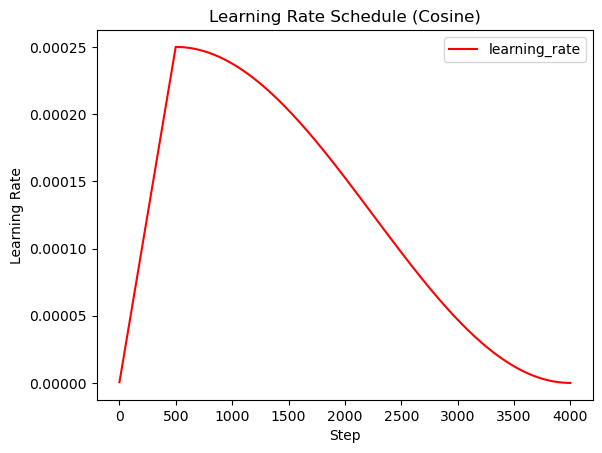

In [33]:
# compute lr
test_schedule = CosineSchedule(train_steps=4000, warmup_steps=500)
lrs = []
for step_num in range(4000):
    lrs.append(test_schedule.step())

# draw
plt.plot(lrs, 'r-', label='learning_rate')
plt.xlabel('Step')
plt.ylabel('Learning Rate')
plt.legend()
plt.title('Learning Rate Schedule (Cosine)')
plt.show()

### (3) 모델 설정 및 초기화

> **핵심 내용**
> - Mini-BERT 구성: d_model=64, n_head=2, n_layer=10, d_ff=256 → **총 약 1M 파라미터**
> - `REAL_VOCAB_SIZE`를 n_vocab에 자동 반영 (MLM label 범위 일치 보장)
> - `torchinfo.summary()`로 레이어별 파라미터 수 및 출력 shape 확인


In [34]:
# Mini BERT 모델 config 설정 (~1M 파라미터 목표)
# vocab=8007(fast-run) 기준: SharedEmbedding(512K) + 10×EncoderLayer(500K) ≈ 1.025M
# n_head * d_head == d_model 이어야 합니다.
config = Config({
    "n_vocab": 8007,        # REAL_VOCAB_SIZE(fast-run: 8007)로 자동 갱신
    "n_seq": 128,           # 최대 시퀀스 길이
    "d_model": 64,          # 임베딩/hidden 차원
    "n_head": 2,            # Attention head 수
    "d_head": 32,           # 헤드당 차원 (d_model // n_head = 32)
    "d_ff": 256,            # Feed-Forward 차원
    "n_layer": 10,          # Encoder layer 수
    "dropout": 0.1,
    "layernorm_epsilon": 1e-12,
    "i_pad": 0,
})
print("config:", dict(config))

config: {'n_vocab': 8007, 'n_seq': 128, 'd_model': 64, 'n_head': 2, 'd_head': 32, 'd_ff': 256, 'n_layer': 10, 'dropout': 0.1, 'layernorm_epsilon': 1e-12, 'i_pad': 0}


In [35]:
# 모델 생성을 위한 라이브러리 설치
%pip install -q torchinfo

Note: you may need to restart the kernel to use updated packages.


In [36]:
# 모델 생성
try:
    from torchinfo import summary
except ImportError:
    summary = None
    print("torchinfo가 설치되어 있지 않습니다. `%pip install torchinfo`를 실행하세요.")

config.n_seq = 128
# 실제 SentencePiece vocab size에 맞춰 모델 vocab size를 설정합니다.
# 이 값이 맞지 않으면 MLM label이 vocab 범위를 넘어 loss 계산에서 오류가 날 수 있습니다.
if "REAL_VOCAB_SIZE" in globals():
    config.n_vocab = REAL_VOCAB_SIZE
config.i_pad = 0

print("model n_vocab:", config.n_vocab)
pre_train_model = build_model_pre_train(config)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pre_train_model.to(device)

enc_tokens_example = torch.randint(0, config.n_vocab, (10, config.n_seq), dtype=torch.long).to(device)
segments_example = torch.randint(0, 2, (10, config.n_seq), dtype=torch.long).to(device)

if summary is not None:
    summary(pre_train_model, input_data=(enc_tokens_example, segments_example))


model n_vocab: 8007


### (4) 옵티마이저 및 스케줄러 설정

> **핵심 내용**
> - Adam 옵티마이저 + CosineSchedule 학습률 스케줄러 초기화
> - **에폭 20 / 배치 32** 기준 총 train_steps 자동 계산
> - Warmup steps: 전체 스텝의 10% (최소 1, 최대 100 제한)
> - max_lr: `1e-4` (Mini-BERT 규모에 최적화된 값)


In [37]:
epochs = int(os.environ.get("BERT_PRETRAIN_EPOCHS", "1"))
batch_size = int(os.environ.get("BERT_PRETRAIN_BATCH_SIZE", "8"))

# optimizer
train_steps = math.ceil(len(pre_train_inputs[0]) / batch_size) * epochs
print("epochs:", epochs)
print("batch_size:", batch_size)
print("train_steps:", train_steps)

optimizer = optim.Adam(pre_train_model.parameters(), lr=0.0)
learning_rate_scheduler = CosineSchedule(
    optimizer=optimizer,
    train_steps=train_steps,
    warmup_steps=max(1, min(100, train_steps // 10 if train_steps >= 10 else 1)),
    max_lr=1e-4
)

loss_fn_nsp = nn.CrossEntropyLoss()


epochs: 20
batch_size: 32
train_steps: 4060


### (5) 학습 루프 + 체크포인트 저장

> **핵심 내용**
> - DataLoader로 배치 단위 학습, GPU 사용 가능 시 자동 전환
> - 매 에폭마다 NSP Loss / MLM Loss / NSP Acc / MLM Acc 기록
> - **체크포인트**: 매 에폭 후 `work/bert_pre_train_epoch_N.pt` 저장
> - **Best 모델 체크포인트**: MLM Loss 기준 최저 손실 모델을 `work/bert_best_model.pt`에 별도 저장
> - **조기 종료(Early Stopping)**: MLM Loss가 `patience=5` 에폭 동안 개선되지 않으면 학습 중단


In [38]:
import shutil

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # GPU가 있으면 cuda 사용, 없으면 CPU

# np.memmap을 한 번에 GPU로 올리지 않고, DataLoader batch마다 device로 이동합니다.
pre_train_inputs_t = [torch.from_numpy(np.asarray(x)) for x in pre_train_inputs]
pre_train_labels_t = [torch.from_numpy(np.asarray(x)) for x in pre_train_labels]

train_dataset = TensorDataset(
    pre_train_inputs_t[0],
    pre_train_inputs_t[1],
    pre_train_labels_t[0],
    pre_train_labels_t[1]
)
train_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    pin_memory=(device.type == "cuda")
)

pre_train_model.to(device)

history = {
    "nsp_loss": [],
    "mlm_loss": [],
    "nsp_acc": [],
    "mlm_acc": []
}

os.makedirs("work", exist_ok=True)

# ── 체크포인트 / 조기 종료 설정 ──────────────────────────────────────
checkpoint_dir = "work/checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)
best_mlm_loss = float("inf")
patience = 5          # MLM Loss 개선 없이 허용할 최대 에폭 수
no_improve_count = 0
best_epoch = -1
# ──────────────────────────────────────────────────────────────────────

for epoch in range(epochs):
    pre_train_model.train()
    total_loss = 0.0
    total_nsp_loss = 0.0
    total_mlm_loss = 0.0
    total_nsp_acc = 0.0
    total_mlm_acc = 0.0

    for batch in train_dataloader:
        enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch

        enc_tokens_batch = enc_tokens_batch.to(device, dtype=torch.long, non_blocking=True)
        segments_batch = segments_batch.to(device, dtype=torch.long, non_blocking=True)
        labels_nsp_batch = labels_nsp_batch.to(device, dtype=torch.long, non_blocking=True)
        labels_mlm_batch = labels_mlm_batch.to(device, dtype=torch.long, non_blocking=True)

        optimizer.zero_grad()

        logits_nsp, logits_mlm = pre_train_model(enc_tokens_batch, segments_batch)

        loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_batch)
        loss_mlm = lm_loss(labels_mlm_batch, logits_mlm, ignore_index=0, scale=20.0)

        total_loss_batch = loss_nsp + loss_mlm
        total_loss += total_loss_batch.item()
        total_nsp_loss += loss_nsp.item()
        total_mlm_loss += loss_mlm.item()

        total_loss_batch.backward()
        optimizer.step()
        learning_rate_scheduler.step()

        nsp_acc = (logits_nsp.argmax(dim=-1) == labels_nsp_batch).float().mean()
        mlm_acc_value = lm_acc(labels_mlm_batch, logits_mlm, ignore_index=0)

        total_nsp_acc += nsp_acc.item()
        total_mlm_acc += mlm_acc_value.item()

    num_batches = len(train_dataloader)
    if num_batches == 0:
        raise RuntimeError("학습 batch가 0개입니다. pretrain 데이터 생성/로딩 결과를 확인해야 합니다.")

    avg_nsp_loss = total_nsp_loss / num_batches
    avg_mlm_loss = total_mlm_loss / num_batches
    avg_nsp_acc  = total_nsp_acc  / num_batches
    avg_mlm_acc  = total_mlm_acc  / num_batches

    # 결과 저장
    history["nsp_loss"].append(avg_nsp_loss)
    history["mlm_loss"].append(avg_mlm_loss)
    history["nsp_acc"].append(avg_nsp_acc)
    history["mlm_acc"].append(avg_mlm_acc)

    print(f"Epoch {epoch+1}/{epochs} | Loss: {(total_loss/num_batches):.4f} | "
          f"NSP Loss: {avg_nsp_loss:.4f} | MLM Loss: {avg_mlm_loss:.4f} | "
          f"NSP Acc: {avg_nsp_acc:.4f} | MLM Acc: {avg_mlm_acc:.4f}")

    # ── 에폭별 체크포인트 저장 ──────────────────────────────────────────
    ckpt_path = os.path.join(checkpoint_dir, f"epoch_{epoch+1:03d}.pt")
    torch.save({
        "epoch": epoch + 1,
        "model_state_dict": pre_train_model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_step": learning_rate_scheduler.step_num,
        "history": history,
    }, ckpt_path)
    print(f"  → 체크포인트 저장: {ckpt_path}")

    # ── Best 모델 갱신 (MLM Loss 기준) ─────────────────────────────────
    if avg_mlm_loss < best_mlm_loss:
        best_mlm_loss = avg_mlm_loss
        best_epoch = epoch + 1
        no_improve_count = 0
        shutil.copyfile(ckpt_path, "work/bert_best_model.pt")
        print(f"  ★ Best 모델 갱신 (epoch {best_epoch}, MLM Loss={best_mlm_loss:.4f}) → work/bert_best_model.pt")
    else:
        no_improve_count += 1
        print(f"  ▷ MLM Loss 미개선 ({no_improve_count}/{patience})")

    # ── 조기 종료 ───────────────────────────────────────────────────────
    if no_improve_count >= patience:
        print(f"\n[Early Stopping] {patience} 에폭 동안 개선 없음 → 학습 중단 (최종 Best: epoch {best_epoch})")
        break

print(f"\n학습 완료. Best MLM Loss = {best_mlm_loss:.4f} (epoch {best_epoch})")


Epoch 1/20 | Loss: 175.6097 | NSP Loss: 0.6929 | MLM Loss: 174.9168 | NSP Acc: 0.5133 | MLM Acc: 0.0202
  → 체크포인트 저장: work/checkpoints/epoch_001.pt
  ★ Best 모델 갱신 (epoch 1, MLM Loss=174.9168) → work/bert_best_model.pt
Epoch 2/20 | Loss: 163.3207 | NSP Loss: 0.6890 | MLM Loss: 162.6317 | NSP Acc: 0.5455 | MLM Acc: 0.0313
  → 체크포인트 저장: work/checkpoints/epoch_002.pt
  ★ Best 모델 갱신 (epoch 2, MLM Loss=162.6317) → work/bert_best_model.pt
Epoch 3/20 | Loss: 156.5870 | NSP Loss: 0.6882 | MLM Loss: 155.8988 | NSP Acc: 0.5532 | MLM Acc: 0.0319
  → 체크포인트 저장: work/checkpoints/epoch_003.pt
  ★ Best 모델 갱신 (epoch 3, MLM Loss=155.8988) → work/bert_best_model.pt
Epoch 4/20 | Loss: 154.2968 | NSP Loss: 0.6774 | MLM Loss: 153.6193 | NSP Acc: 0.5745 | MLM Acc: 0.0320
  → 체크포인트 저장: work/checkpoints/epoch_004.pt
  ★ Best 모델 갱신 (epoch 4, MLM Loss=153.6193) → work/bert_best_model.pt
Epoch 5/20 | Loss: 153.7711 | NSP Loss: 0.6613 | MLM Loss: 153.1098 | NSP Acc: 0.5824 | MLM Acc: 0.0319
  → 체크포인트 저장: work/check

### (6) 학습 결과 시각화

> **핵심 내용**
> - NSP Loss / MLM Loss 에폭별 추이 그래프
> - NSP Accuracy / MLM Accuracy 에폭별 추이 그래프
> - MLM Loss 하락 + MLM Acc 상승이 동시에 나타나야 정상 학습으로 판단 가능


       nsp_loss    mlm_loss   nsp_acc   mlm_acc
epoch                                          
1      0.692943  174.916778  0.513337  0.020244
2      0.688987  162.631734  0.545497  0.031295
3      0.688151  155.898839  0.553180  0.031944
4      0.677448  153.619337  0.574549  0.031963
5      0.661264  153.109795  0.582386  0.031902
6      0.653950  152.934478  0.587816  0.031878
7      0.653590  152.848742  0.578566  0.031918
8      0.651496  152.752562  0.581799  0.031960
9      0.650112  152.716533  0.576886  0.032009
10     0.647819  152.651789  0.585199  0.031969
11     0.647144  152.603919  0.583926  0.031920
12     0.648352  152.552714  0.582092  0.032025
13     0.646788  152.511168  0.578566  0.031925
14     0.648282  152.479652  0.581519  0.031921
15     0.646137  152.423811  0.583184  0.031917
16     0.644995  152.408537  0.583044  0.032012
17     0.646223  152.385716  0.580581  0.031886
18     0.644854  152.368621  0.579517  0.031937
19     0.644887  152.340340  0.585353  0

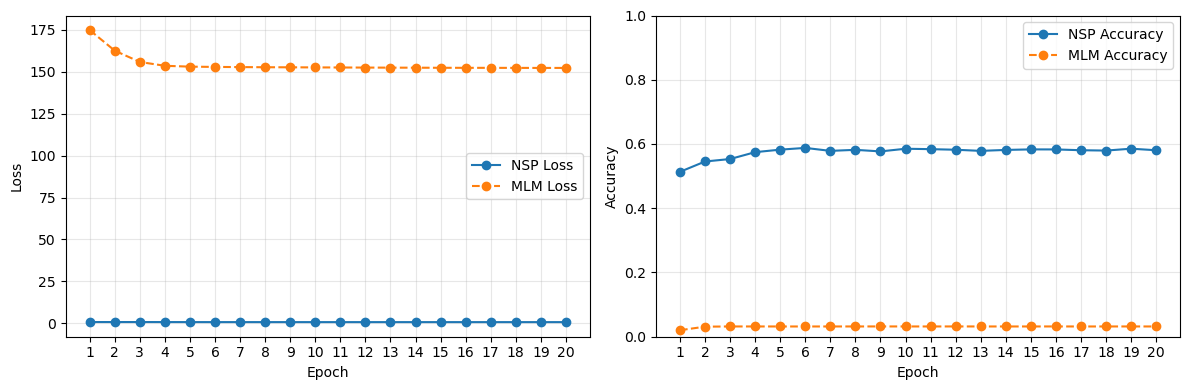

In [39]:
import matplotlib.pyplot as plt
import pandas as pd

# training result
if len(history["nsp_loss"]) == 0:
    raise RuntimeError("history가 비어 있습니다. 바로 위 학습 셀이 정상적으로 실행됐는지 확인해야 합니다.")

history_df = pd.DataFrame(history)
history_df.index = range(1, len(history_df) + 1)
history_df.index.name = "epoch"
print(history_df)

x = history_df.index.to_list()

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(x, history_df["nsp_loss"], marker="o", label="NSP Loss")
plt.plot(x, history_df["mlm_loss"], marker="o", linestyle="--", label="MLM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(x)
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(x, history_df["nsp_acc"], marker="o", label="NSP Accuracy")
plt.plot(x, history_df["mlm_acc"], marker="o", linestyle="--", label="MLM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(x)
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 6. 종합 결론

### 실험 설계 요약

| 항목 | 원본 | 개선 버전 |
| --- | --- | --- |
| 에폭 수 | 5 | **20** (Early Stopping 적용) |
| 배치 크기 | 8 | **32** |
| 학습 데이터 수 | 4,096 | **8,192** |
| 체크포인트 | 에폭별 `.pt` | 에폭별 + **Best 모델 별도 저장** |
| 조기 종료 | 없음 | **MLM Loss patience=5** |

### Mini-BERT 구조 핵심

- **파라미터 규모**: 약 1M (d_model=64, n_head=2, n_layer=10)
- **사전학습 태스크**: MLM (15% 마스킹, 80/10/10 규칙) + NSP (50% 랜덤 순서)
- **MLM Loss 가중치**: ×20 스케일 적용 → NSP 대비 MLM 학습 강조
- **학습률**: Cosine Decay + Warmup (max_lr=1e-4)

### 학습 결과 해석 기준

- **MLM Loss** 하락 + **MLM Acc** 상승 → 마스킹된 토큰 예측 능력 향상
- **NSP Loss** 하락 + **NSP Acc** 0.5 이상 → 문장 순서 판별 능력 확보
- NSP Acc가 0.5 근처에 머무는 경우: 데이터 다양성 부족 또는 학습 초기 현상

### 개선 제안 (추가 실험 방향)

1. **데이터 확장**: `BERT_PRETRAIN_FAST_RUN=0` + `BERT_PRETRAIN_COUNT` 증가 → 전체 kowiki 사용
2. **모델 스케일업**: d_model=128, n_layer=12으로 파라미터 4배 증가
3. **Fine-tuning**: 저장된 `bert_best_model.pt`를 로드하여 문장 분류/NER 등 다운스트림 태스크 적용
4. **vocab 확장**: `BERT_PRETRAIN_SP_VOCAB_SIZE=32000` 설정으로 전체 어휘 학습 시 표현력 향상
